# Task 1 — cross-fold feature importance and model capacity

*Can a classifier identify which treatment condition a cell came from
using its gene expression profile? Which genes drive the separation?*

**Input.** `data/dataset_hv.h5ad` — 216,431 QC-passing cells x 1,011 genes (1,000 seurat-flavour
highly variable genes + 29 markers taken from Frangieh et al. 2021), CP10K + log1p, CSR. 

**Label.** `obs['condition']` — `Co-culture` (72,398 cells), `Control` (57,039), `IFNγ` (86,994)
after QC.

**What is computed, per fold, on one shared `StratifiedKFold(5, shuffle=True, random_state=123)`
split:**

| model | capacity | importance measure |
|---|---|---|
| `xgb6` | 6 boosting rounds (the setting in `src/models.py`) | mean \|SHAP\| (TreeExplainer) |
| `xgb_hi` | up to 400 rounds, early stopping on a 15 % validation slice of the training cells | mean \|SHAP\| (TreeExplainer) |
| `mlp` | 1011 → 128 → 64 → 3, dropout 0.2, Adam, 8 epochs | mean \|gradient x input\| |

All three models see identical training cells and identical held-out cells in each fold, and all
three importance vectors are evaluated on the **same** ~5,000-cell subsample of that fold's held-out
cells. Every gene therefore gets a mean, a standard deviation, a rank spread and a top-20 hit count
across the five folds, and the XGBoost/MLP rankings are directly comparable.

Shared machinery lives in `src/task1_cv.py`

In [1]:
# Writable cache directories
import os
import tempfile
from pathlib import Path

CACHE_DIR = Path(tempfile.gettempdir()) / "sc-course-2026-cache"
for sub in ("matplotlib", "numba"):
    (CACHE_DIR / sub).mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_DIR / "numba"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))

'/tmp/sc-course-2026-cache'

In [2]:
import json
import sys
import time

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
import task1_cv as T  # noqa: E402

DATA = REPO / "data"
FIGDIR = REPO / "figures"
FIGDIR.mkdir(exist_ok=True)

SEED = T.SEED
N_FOLDS = 5
N_IMPORTANCE_CELLS = 5000   # per fold, drawn from that fold's held-out cells
XGB_LOW_ROUNDS = 6          # src/models.py fit_xgb default
XGB_HI_ROUNDS = 400         # with early stopping; effective size reported below
TOP_N = 20

print("numpy", np.__version__, "| scanpy", sc.__version__)

numpy 2.5.2 | scanpy 1.12.3


/tmp/ipykernel_860509/189467403.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("numpy", np.__version__, "| scanpy", sc.__version__)


## 1. Data, labels and the shared fold split

The fold indices are materialised once here and reused by every model in the notebook. Fold-wise
importances are only comparable across models because of this.

In [3]:
cache = DATA / "dataset_hv.h5ad"
if not cache.exists():
    raise FileNotFoundError(f"{cache} is missing. Run: python src/prepare_data.py")
adata = sc.read_h5ad(cache)
X = adata.X if sp.isspmatrix_csr(adata.X) else adata.X.tocsr()
genes = pd.Index(adata.var_names)
y = adata.obs["condition"].cat.codes.to_numpy().astype(np.int64)
class_names = list(adata.obs["condition"].cat.categories)
n_classes = len(class_names)

folds = T.fold_splits(y, n_splits=N_FOLDS, seed=SEED)
subsamples = {
    k: T.fold_subsample(te, N_IMPORTANCE_CELLS, fold=k, seed=SEED)
    for k, (tr, te) in enumerate(folds)
}

print(f"{X.shape[0]:,} cells x {X.shape[1]:,} genes  ({X.dtype}, {100 * X.nnz / np.prod(X.shape):.1f} % nonzero)")
print("classes:", dict(zip(class_names, np.bincount(y))))
print("fold test sizes:", [len(te) for _, te in folds])
print("importance subsample per fold:", {k: len(v) for k, v in subsamples.items()})

216,431 cells x 1,011 genes  (float32, 8.4 % nonzero)
classes: {'Co-culture': np.int64(72398), 'Control': np.int64(57039), 'IFNγ': np.int64(86994)}
fold test sizes: [43287, 43286, 43286, 43286, 43286]
importance subsample per fold: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000}


## 2. Baselines for a 3-class imbalanced problem

Balanced accuracy is the mean per-class recall, so for three classes every label-agnostic strategy
sits at 1/3 in expectation - including "always predict the largest class", which would reach 40 % raw
accuracy. These numbers are what the fold accuracies below have to be read against.

In [4]:
base = T.baselines(y, seed=SEED)
print(json.dumps(base, indent=2))

{
  "majority_class": 0.3333333333333333,
  "stratified_random_mean": 0.3333124366763988,
  "stratified_random_sd": 0.00095190860766801,
  "uniform_random_mean": 0.33316346003066927,
  "uniform_random_sd": 0.0010094551201124636,
  "chance_1_over_k": 0.3333333333333333,
  "class_frequencies": {
    "0": 0.3345084576608711,
    "1": 0.26354357739880147,
    "2": 0.4019479649403274
  }
}


## 3. Fold loop — three models, shared folds, shared importance subsample

For each fold: fit `xgb6`, `xgb_hi` and `mlp` on the fold's training cells; score balanced accuracy
on the held-out cells; compute the importance vector on that fold's shared subsample.

`xgb_hi` carves a stratified 15 % validation slice out of the **training** cells for early stopping,
so the held-out cells stay untouched and the fold accuracy stays honest.

In [5]:
device = T.get_device()
print("torch device:", device)

imp = {m: T.FoldImportance(m, genes) for m in ("xgb6", "xgb_hi", "mlp")}
fold_rows = []
confusions = {m: np.zeros((n_classes, n_classes), dtype=np.int64) for m in imp}
xgb_hi_rounds = []
mlp_histories = []

for k, (train_idx, test_idx) in enumerate(folds):
    sub = subsamples[k]
    X_sub_dense = np.asarray(X[sub].todense(), dtype=np.float32)
    t_fold = time.time()

    # -- gradient boosting, both capacities ------------------------------- #
    for tag, n_est, es in (("xgb6", XGB_LOW_ROUNDS, None), ("xgb_hi", XGB_HI_ROUNDS, 25)):
        t0 = time.time()
        bst = T.fit_xgb_fold(
            X, y, train_idx, n_estimators=n_est, feature_names=genes,
            early_stopping_rounds=es,
        )
        pred = bst.predict(X[test_idx])
        acc = balanced_accuracy_score(y[test_idx], pred)
        confusions[tag] += confusion_matrix(y[test_idx], pred, labels=np.arange(n_classes))
        imp[tag].per_fold[k] = T.shap_importance(bst, X_sub_dense, n_classes)
        n_trees = bst.get_booster().num_boosted_rounds()
        if tag == "xgb_hi":
            xgb_hi_rounds.append(n_trees)
        fold_rows.append({"model": tag, "fold": k, "balanced_accuracy": acc,
                          "n_rounds": n_trees, "fit_seconds": round(time.time() - t0, 1)})
        print(f"fold {k} {tag:7s} acc {acc:.4f} ({n_trees} rounds, {time.time() - t0:.0f}s)", flush=True)

    # -- MLP -------------------------------------------------------------- #
    t0 = time.time()
    mlp, hist = T.fit_mlp(X, y, train_idx, device)
    hist["fold"] = k
    mlp_histories.append(hist)
    pred = T.predict_mlp(mlp, X, test_idx, device)
    acc = balanced_accuracy_score(y[test_idx], pred)
    confusions["mlp"] += confusion_matrix(y[test_idx], pred, labels=np.arange(n_classes))
    imp["mlp"].per_fold[k] = T.grad_x_input_importance(mlp, X, y, sub, device)
    fold_rows.append({"model": "mlp", "fold": k, "balanced_accuracy": acc,
                      "n_rounds": np.nan, "fit_seconds": round(time.time() - t0, 1)})
    print(f"fold {k} {'mlp':7s} acc {acc:.4f} ({time.time() - t0:.0f}s)"
          f"  [fold total {time.time() - t_fold:.0f}s]", flush=True)

    del X_sub_dense

fold_df = pd.DataFrame(fold_rows)

torch device: cpu


/home/ubuntu/miniforge/envs/sc-course-2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


fold 0 xgb6    acc 0.9726 (6 rounds, 2s)
fold 0 xgb_hi  acc 0.9877 (400 rounds, 60s)
fold 0 mlp     acc 0.9861 (12s)  [fold total 74s]
fold 1 xgb6    acc 0.9705 (6 rounds, 2s)
fold 1 xgb_hi  acc 0.9882 (400 rounds, 57s)
fold 1 mlp     acc 0.9852 (11s)  [fold total 70s]
fold 2 xgb6    acc 0.9704 (6 rounds, 2s)
fold 2 xgb_hi  acc 0.9877 (400 rounds, 57s)
fold 2 mlp     acc 0.9840 (11s)  [fold total 69s]
fold 3 xgb6    acc 0.9676 (6 rounds, 2s)
fold 3 xgb_hi  acc 0.9879 (400 rounds, 57s)
fold 3 mlp     acc 0.9855 (11s)  [fold total 70s]
fold 4 xgb6    acc 0.9694 (6 rounds, 2s)
fold 4 xgb_hi  acc 0.9885 (400 rounds, 57s)
fold 4 mlp     acc 0.9840 (11s)  [fold total 70s]


In [6]:
acc_table = (
    fold_df.groupby("model")["balanced_accuracy"]
    .agg(mean="mean", sd=lambda s: s.std(ddof=1), min="min", max="max")
    .reindex(["xgb6", "xgb_hi", "mlp"])
)
acc_table["n_folds"] = N_FOLDS
print(acc_table.round(4).to_string())
print(f"\nxgb_hi boosting rounds actually used per fold: {xgb_hi_rounds}")

          mean      sd     min     max  n_folds
model                                          
xgb6    0.9701  0.0018  0.9676  0.9726        5
xgb_hi  0.9880  0.0003  0.9877  0.9885        5
mlp     0.9850  0.0010  0.9840  0.9861        5

xgb_hi boosting rounds actually used per fold: [400, 400, 400, 400, 400]


## 4. Per-gene importance across folds

`mean_importance` / `sd_importance` are the across-fold mean and SD of the per-gene importance;
`n_folds_in_top20` counts in how many of the five folds a gene appeared in that model's own top 20,
which is the stability measure that does not depend on the (different, non-comparable) importance
units of the two model families.

In [7]:
summaries = {m: fi.summary(top_n=TOP_N) for m, fi in imp.items()}
importance_long = pd.concat([fi.frame() for fi in imp.values()], ignore_index=True)
importance_table = pd.concat(summaries.values()).reset_index()

for m in ("xgb6", "xgb_hi", "mlp"):
    s = summaries[m].head(TOP_N)
    print(f"\n=== {m}: top {TOP_N} genes by mean fold importance ===")
    print(s[["mean_importance", "sd_importance", "mean_rank", "best_rank",
             "worst_rank", f"n_folds_in_top{TOP_N}"]].to_string(float_format=lambda v: f"{v:.4g}"))


=== xgb6: top 20 genes by mean fold importance ===
            mean_importance  sd_importance  mean_rank  best_rank  worst_rank  n_folds_in_top20
gene                                                                                          
HLA-B               0.07095       0.001093          1          1           1                 5
WARS                0.05311       0.004503        2.6          2           3                 5
GBP1                0.05243       0.004508          3          2           5                 5
IDO1                0.04594       0.001716        4.4          4           5                 5
CD74                0.04495       0.004804          4          3           5                 5
PFN1                0.02282       0.002136        6.4          6           7                 5
TEX29               0.01974        0.01446        7.4          6          11                 5
FN1                0.008726       0.001645        8.2          7           9                 

## 5. Does raising XGBoost capacity change the ranking?

`src/models.py` defaults to `n_estimators=6`. Six multiclass rounds give 18 trees over 1,011
features, so most genes are never selected for a split and receive exactly zero SHAP mass. The
comparison below reports how many genes each capacity actually uses, and the rank correlation between
the two — over all genes, and restricted to the union of their top 50, where a ranking difference
would change which genes an interpretation is drawn from.

In [8]:
def rank_agreement(a, b, gene_index, k=50, label=""):
    a, b = np.asarray(a), np.asarray(b)
    union = sorted(set(np.argsort(-a)[:k]) | set(np.argsort(-b)[:k]))
    top_a, top_b = set(np.argsort(-a)[:k]), set(np.argsort(-b)[:k])
    return {
        "comparison": label,
        "spearman_all_genes": spearmanr(a, b).statistic,
        "kendall_all_genes": kendalltau(a, b).statistic,
        f"spearman_union_top{k}": spearmanr(a[union], b[union]).statistic,
        f"jaccard_top{k}": len(top_a & top_b) / len(top_a | top_b),
        f"overlap_top{k}": len(top_a & top_b),
        f"n_union_top{k}": len(union),
    }

mean_imp = {m: summaries[m]["mean_importance"].reindex(genes).to_numpy() for m in imp}

capacity = pd.DataFrame([
    rank_agreement(mean_imp["xgb6"], mean_imp["xgb_hi"], genes, label="xgb6 vs xgb_hi"),
])
print(capacity.T.to_string(header=False, float_format=lambda v: f"{v:.4g}"))

used = pd.DataFrame({
    "model": ["xgb6", "xgb_hi", "mlp"],
    "genes_with_nonzero_mean_importance": [int((mean_imp[m] > 0).sum()) for m in ("xgb6", "xgb_hi", "mlp")],
    "share_of_1011": [float((mean_imp[m] > 0).mean()) for m in ("xgb6", "xgb_hi", "mlp")],
})
print()
print(used.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

comparison            xgb6 vs xgb_hi
spearman_all_genes            0.6972
kendall_all_genes             0.6226
spearman_union_top50          0.1705
jaccard_top50                 0.3699
overlap_top50                     27
n_union_top50                     73

 model  genes_with_nonzero_mean_importance  share_of_1011
  xgb6                                 174          0.172
xgb_hi                                 375          0.371
   mlp                                 974          0.963


## 6. Rank concordance between the two required model types

The two importance measures are not on a common scale (mean \|SHAP\| in logit units vs mean
\|gradient x input\|), so only ranks are compared. `xgb_hi` is used as the gradient-boosting side
because it is the fitted model; the `xgb6` comparison is kept for reference.

In [9]:
concordance = pd.DataFrame([
    rank_agreement(mean_imp["xgb_hi"], mean_imp["mlp"], genes, label="xgb_hi vs mlp"),
    rank_agreement(mean_imp["xgb6"], mean_imp["mlp"], genes, label="xgb6 vs mlp"),
    rank_agreement(mean_imp["xgb6"], mean_imp["xgb_hi"], genes, label="xgb6 vs xgb_hi"),
])
print(concordance.set_index("comparison").T.to_string(float_format=lambda v: f"{v:.4g}"))

shared_top = [g for g in summaries["xgb_hi"].head(TOP_N).index if g in set(summaries["mlp"].head(TOP_N).index)]
print(f"\ngenes in the top {TOP_N} of BOTH xgb_hi and mlp ({len(shared_top)}): {shared_top}")

comparison            xgb_hi vs mlp  xgb6 vs mlp  xgb6 vs xgb_hi
spearman_all_genes           0.8175       0.6063          0.6972
kendall_all_genes            0.6786       0.4844          0.6226
spearman_union_top50         0.2634      0.05187          0.1705
jaccard_top50                0.4925       0.2987          0.3699
overlap_top50                    33           23              27
n_union_top50                    67           77              73

genes in the top 20 of BOTH xgb_hi and mlp (13): ['HLA-B', 'CD74', 'WARS', 'PFN1', 'IDO1', 'GBP1', 'HLA-DRA', 'FN1', 'GBP4', 'PMEPA1', 'GBP2', 'PTGES', 'LAP3']


## 7. Confusion structure

Counts pooled over the five folds, so every cell in the dataset is counted exactly once as a
held-out cell. Rows are true condition, columns predicted; the right-hand table is row-normalised.

In [10]:
for m in ("xgb6", "xgb_hi", "mlp"):
    cm = pd.DataFrame(confusions[m], index=class_names, columns=class_names)
    print(f"\n=== {m} (pooled over {N_FOLDS} folds, n={confusions[m].sum():,}) ===")
    print(cm.to_string())
    print((cm.div(cm.sum(axis=1), axis=0) * 100).round(2).to_string())

offdiag = []
for m in ("xgb6", "xgb_hi", "mlp"):
    cm = confusions[m]
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                offdiag.append({"model": m, "true": class_names[i], "predicted": class_names[j],
                                "n": int(cm[i, j]), "pct_of_true_class": 100 * cm[i, j] / cm[i].sum()})
confusion_pairs = pd.DataFrame(offdiag).sort_values(["model", "n"], ascending=[True, False])
print("\nlargest error cell per model:")
print(confusion_pairs.groupby("model").head(1).to_string(index=False, float_format=lambda v: f"{v:.2f}"))


=== xgb6 (pooled over 5 folds, n=216,431) ===
            Co-culture  Control   IFNγ
Co-culture       70168      681   1549
Control            338    55150   1551
IFNγ               220     2029  84745
            Co-culture  Control   IFNγ
Co-culture       96.92     0.94   2.14
Control           0.59    96.69   2.72
IFNγ              0.25     2.33  97.41

=== xgb_hi (pooled over 5 folds, n=216,431) ===
            Co-culture  Control   IFNγ
Co-culture       71983      263    152
Control             74    56566    399
IFNγ                98     1812  85084
            Co-culture  Control   IFNγ
Co-culture       99.43     0.36   0.21
Control           0.13    99.17   0.70
IFNγ              0.11     2.08  97.80

=== mlp (pooled over 5 folds, n=216,431) ===
            Co-culture  Control   IFNγ
Co-culture       71857      312    229
Control            231    56156    652
IFNγ               215     1713  85066
            Co-culture  Control   IFNγ
Co-culture       99.25     0.43   0.32


## 8. Paper-marker membership of the top-ranked genes

`var['paper_marker']` flags the 29 genes taken from Frangieh et al. 2021 that were force-included in
the feature set. 

In [11]:
paper_markers = set(adata.var_names[adata.var["paper_marker"].to_numpy().astype(bool)])
hvg_only = set(adata.var_names[adata.var["highly_variable"].to_numpy().astype(bool)]) - paper_markers

marker_rows = []
for m in ("xgb6", "xgb_hi", "mlp"):
    top = summaries[m].head(TOP_N).index
    marker_rows.append({
        "model": m,
        f"paper_markers_in_top{TOP_N}": int(sum(g in paper_markers for g in top)),
        f"markers": ", ".join(g for g in top if g in paper_markers),
    })
print(pd.DataFrame(marker_rows).to_string(index=False))

importance_table["is_paper_marker"] = importance_table["gene"].isin(paper_markers)
print(f"\n{len(paper_markers)} paper markers in the feature set; "
      f"{len(hvg_only)} HVG-only genes.")

 model  paper_markers_in_top20                                                                      markers
  xgb6                       9                  HLA-B, GBP1, IDO1, CD74, TEX29, HLA-DRA, PTGES, CYP2S1, CD7
xgb_hi                      11 HLA-B, CD74, IDO1, GBP1, HLA-DRA, TEX29, HLA-DRB1, CXCL9, PTGES, CD7, HAPLN3
   mlp                       6                                      HLA-B, CD74, GBP1, IDO1, PTGES, HLA-DRA

30 paper markers in the feature set; 981 HVG-only genes.


## 9. Write the tables

Three CSVs under `data/`, plus the JSON the observations file reads:

* `task1_accuracy_table.csv` — per-model balanced accuracy (mean, SD, range) and every baseline;
* `task1_gene_importance.csv` — per-gene, per-model mean/SD/rank-spread/top-20 hit count;
* `task1_fold_importance_long.csv` — the raw per-fold, per-gene importances behind them;
* `task1_confusion_pairs.csv` — every off-diagonal confusion cell.

In [12]:
acc_out = acc_table.reset_index().rename(columns={"index": "model"})
acc_out["kind"] = "model"
base_rows = [
    {"model": "baseline_majority_class", "mean": base["majority_class"], "kind": "baseline"},
    {"model": "baseline_stratified_random", "mean": base["stratified_random_mean"],
     "sd": base["stratified_random_sd"], "kind": "baseline"},
    {"model": "baseline_uniform_random", "mean": base["uniform_random_mean"],
     "sd": base["uniform_random_sd"], "kind": "baseline"},
    {"model": "chance_1_over_k", "mean": base["chance_1_over_k"], "kind": "baseline"},
]
acc_out = pd.concat([acc_out, pd.DataFrame(base_rows)], ignore_index=True)
acc_out.to_csv(DATA / "task1_accuracy_table.csv", index=False)

importance_table.to_csv(DATA / "task1_gene_importance.csv", index=False)
importance_long.to_csv(DATA / "task1_fold_importance_long.csv", index=False)
confusion_pairs.to_csv(DATA / "task1_confusion_pairs.csv", index=False)
pd.concat(mlp_histories, ignore_index=True).to_csv(DATA / "task1_mlp_training_history.csv", index=False)

payload = {
    "n_cells": int(adata.n_obs), "n_genes": int(adata.n_vars),
    "class_names": class_names, "class_counts": {c: int(n) for c, n in zip(class_names, np.bincount(y))},
    "n_folds": N_FOLDS, "seed": SEED, "n_importance_cells_per_fold": int(N_IMPORTANCE_CELLS),
    "xgb_low_rounds": XGB_LOW_ROUNDS, "xgb_hi_max_rounds": XGB_HI_ROUNDS,
    "xgb_hi_rounds_used": [int(v) for v in xgb_hi_rounds],
    "accuracies": {
        m: {"mean": float(acc_table.loc[m, "mean"]), "sd": float(acc_table.loc[m, "sd"]),
            "min": float(acc_table.loc[m, "min"]), "max": float(acc_table.loc[m, "max"]),
            "per_fold": [float(v) for v in fold_df.loc[fold_df.model == m, "balanced_accuracy"]]}
        for m in ("xgb6", "xgb_hi", "mlp")
    },
    "baselines": base,
    "genes_with_nonzero_importance": {m: int((mean_imp[m] > 0).sum()) for m in imp},
    "top_genes": {m: list(summaries[m].head(TOP_N).index) for m in imp},
    "top_genes_stability": {
        m: {g: int(summaries[m].loc[g, f"n_folds_in_top{TOP_N}"]) for g in summaries[m].head(TOP_N).index}
        for m in imp
    },
    "concordance": concordance.to_dict("records"),
    "confusion": {m: confusions[m].tolist() for m in imp},
    "paper_markers_in_feature_set": sorted(paper_markers),
    "shared_top_genes_xgbhi_mlp": shared_top,
}
(DATA / "task1_cv_results.json").write_text(json.dumps(payload, indent=2))
print("wrote:", *[p.name for p in sorted(DATA.glob("task1_*"))], sep="\n  ")

wrote:
  task1_accuracy_table.csv
  task1_confusion_pairs.csv
  task1_cv_results.json
  task1_fold_importance_long.csv
  task1_gene_importance.csv
  task1_mlp_training_history.csv


## Figures

The four figures are built by `tools/task1_figures.py`, which reads only the CSV/JSON
tables written above.  It is a module rather than inline cells so the figures can be
regenerated without re-running the 5-fold loop. 

  task1_fig1_importance_stability.png: 0 overlaps, 0 outside
wrote figures/task1_fig1_importance_stability.png
  task1_fig2_rank_concordance.png: 0 overlaps, 0 outside
wrote figures/task1_fig2_rank_concordance.png
  task1_fig3_confusion.png: 0 overlaps, 0 outside
wrote figures/task1_fig3_confusion.png
  task1_fig4_accuracy_capacity.png: 0 overlaps, 0 outside
wrote figures/task1_fig4_accuracy_capacity.png


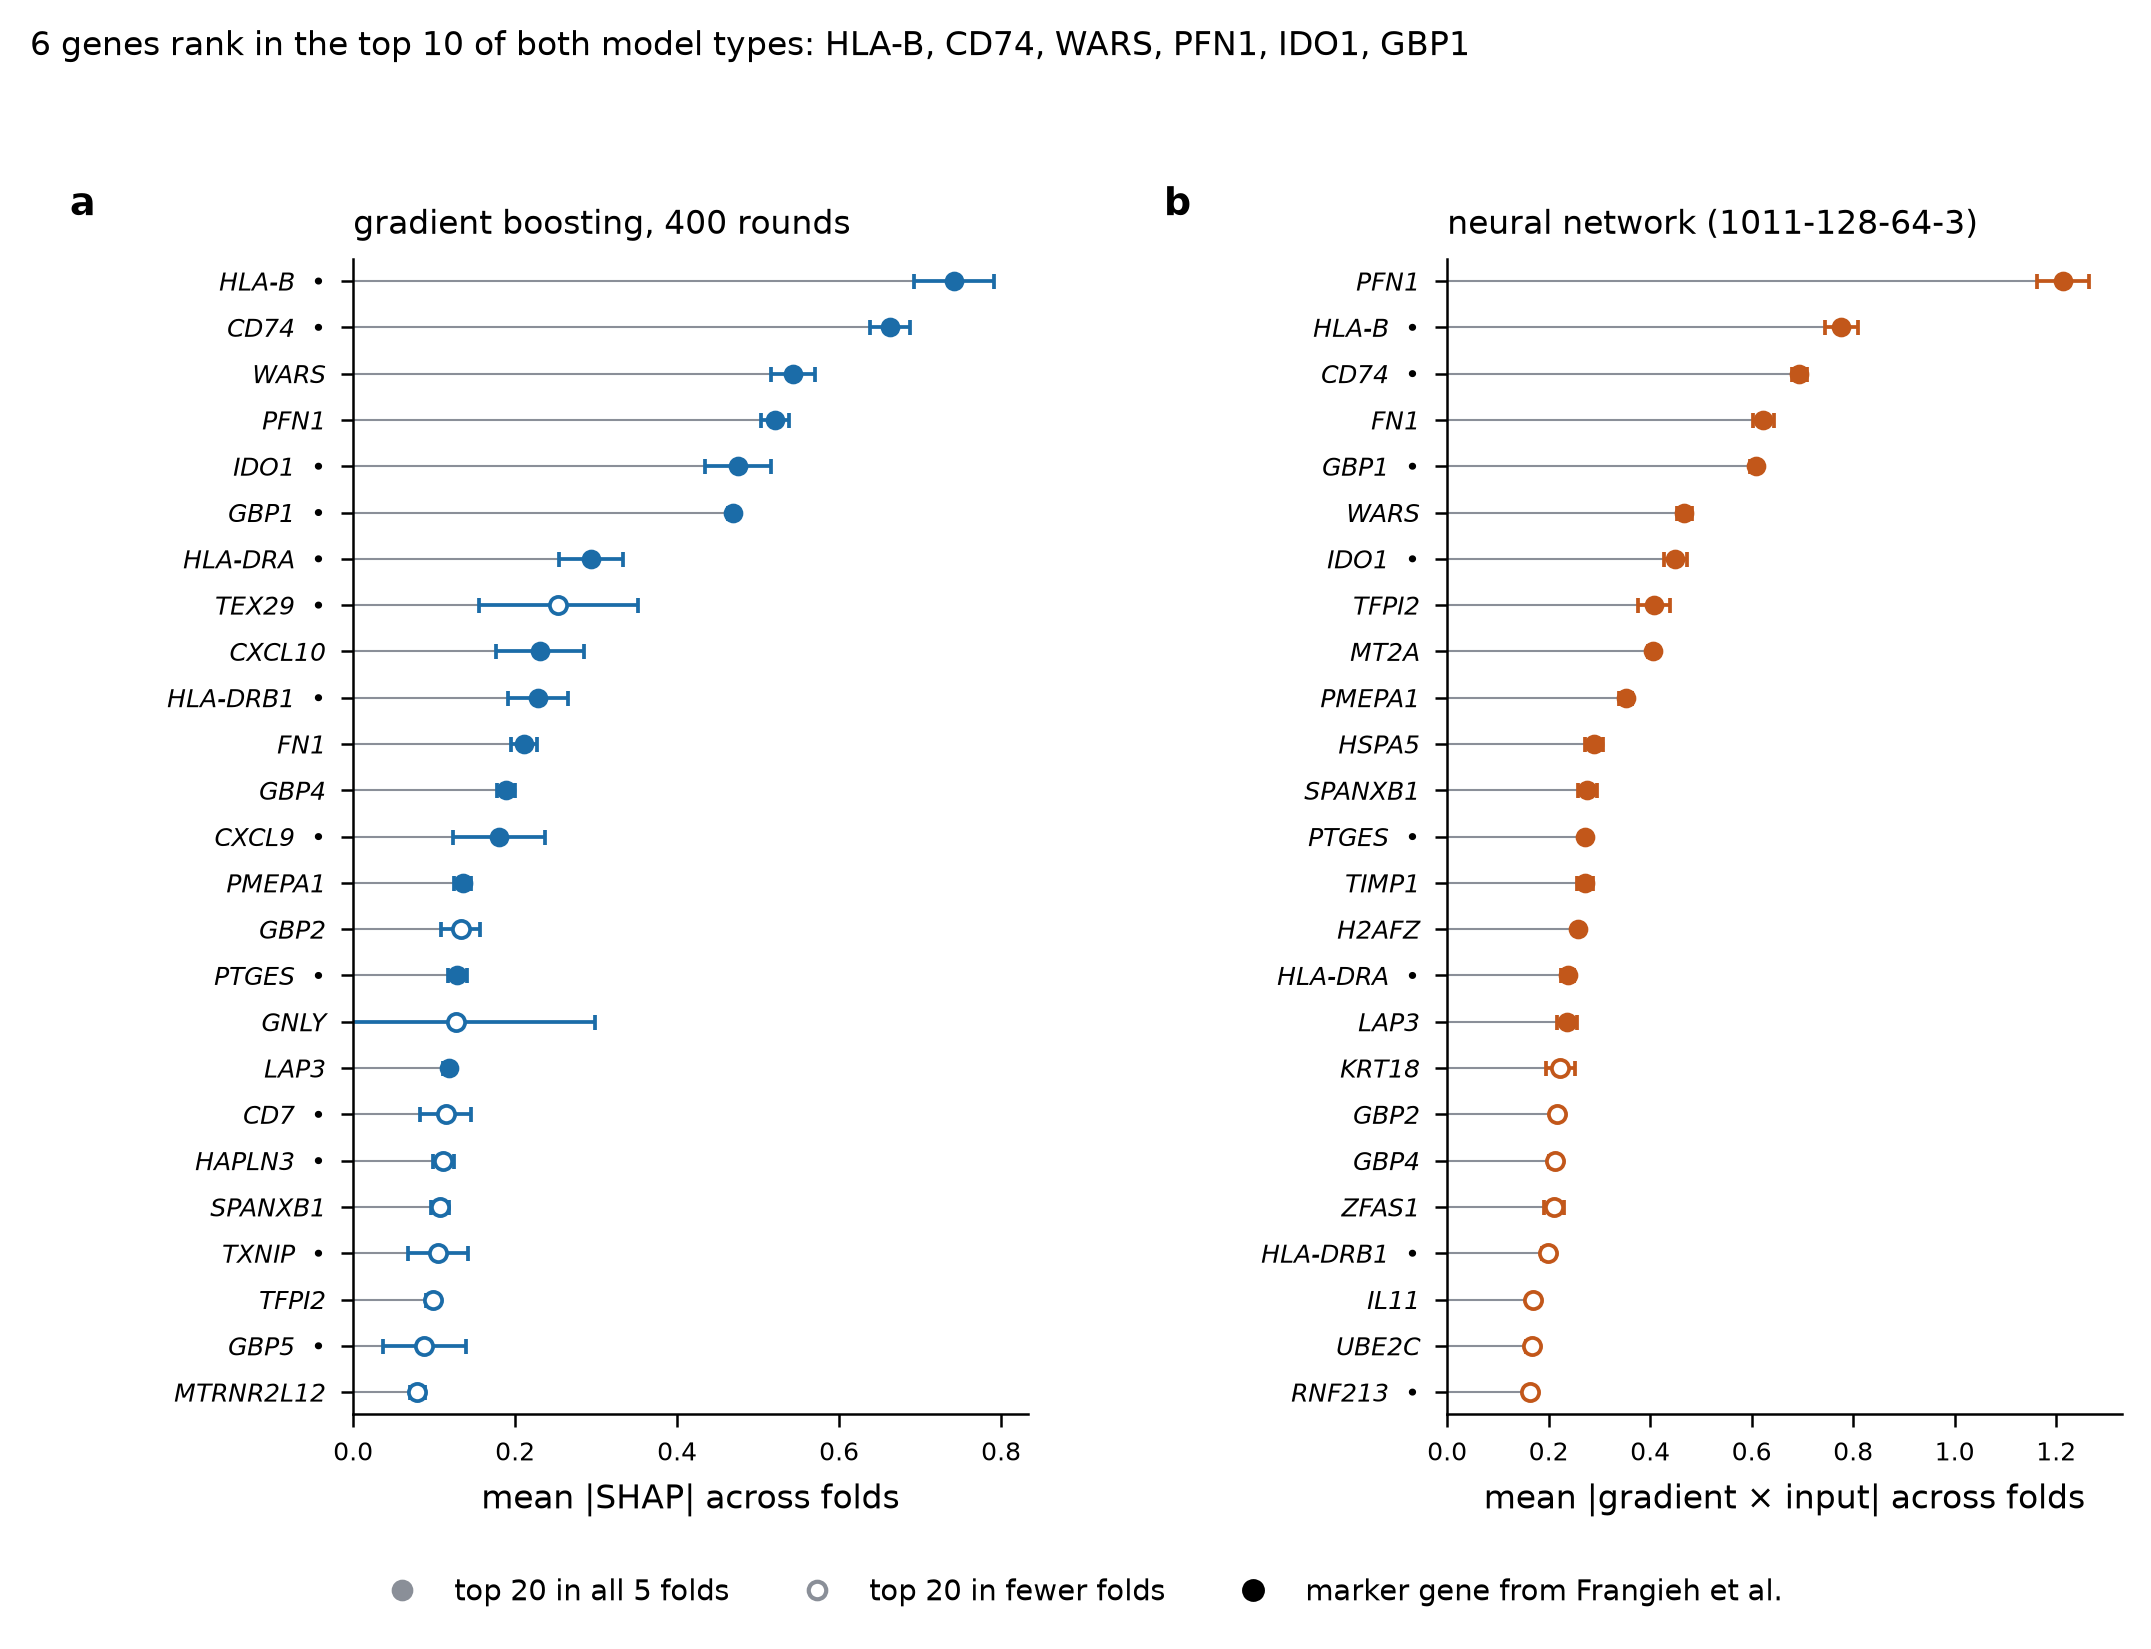

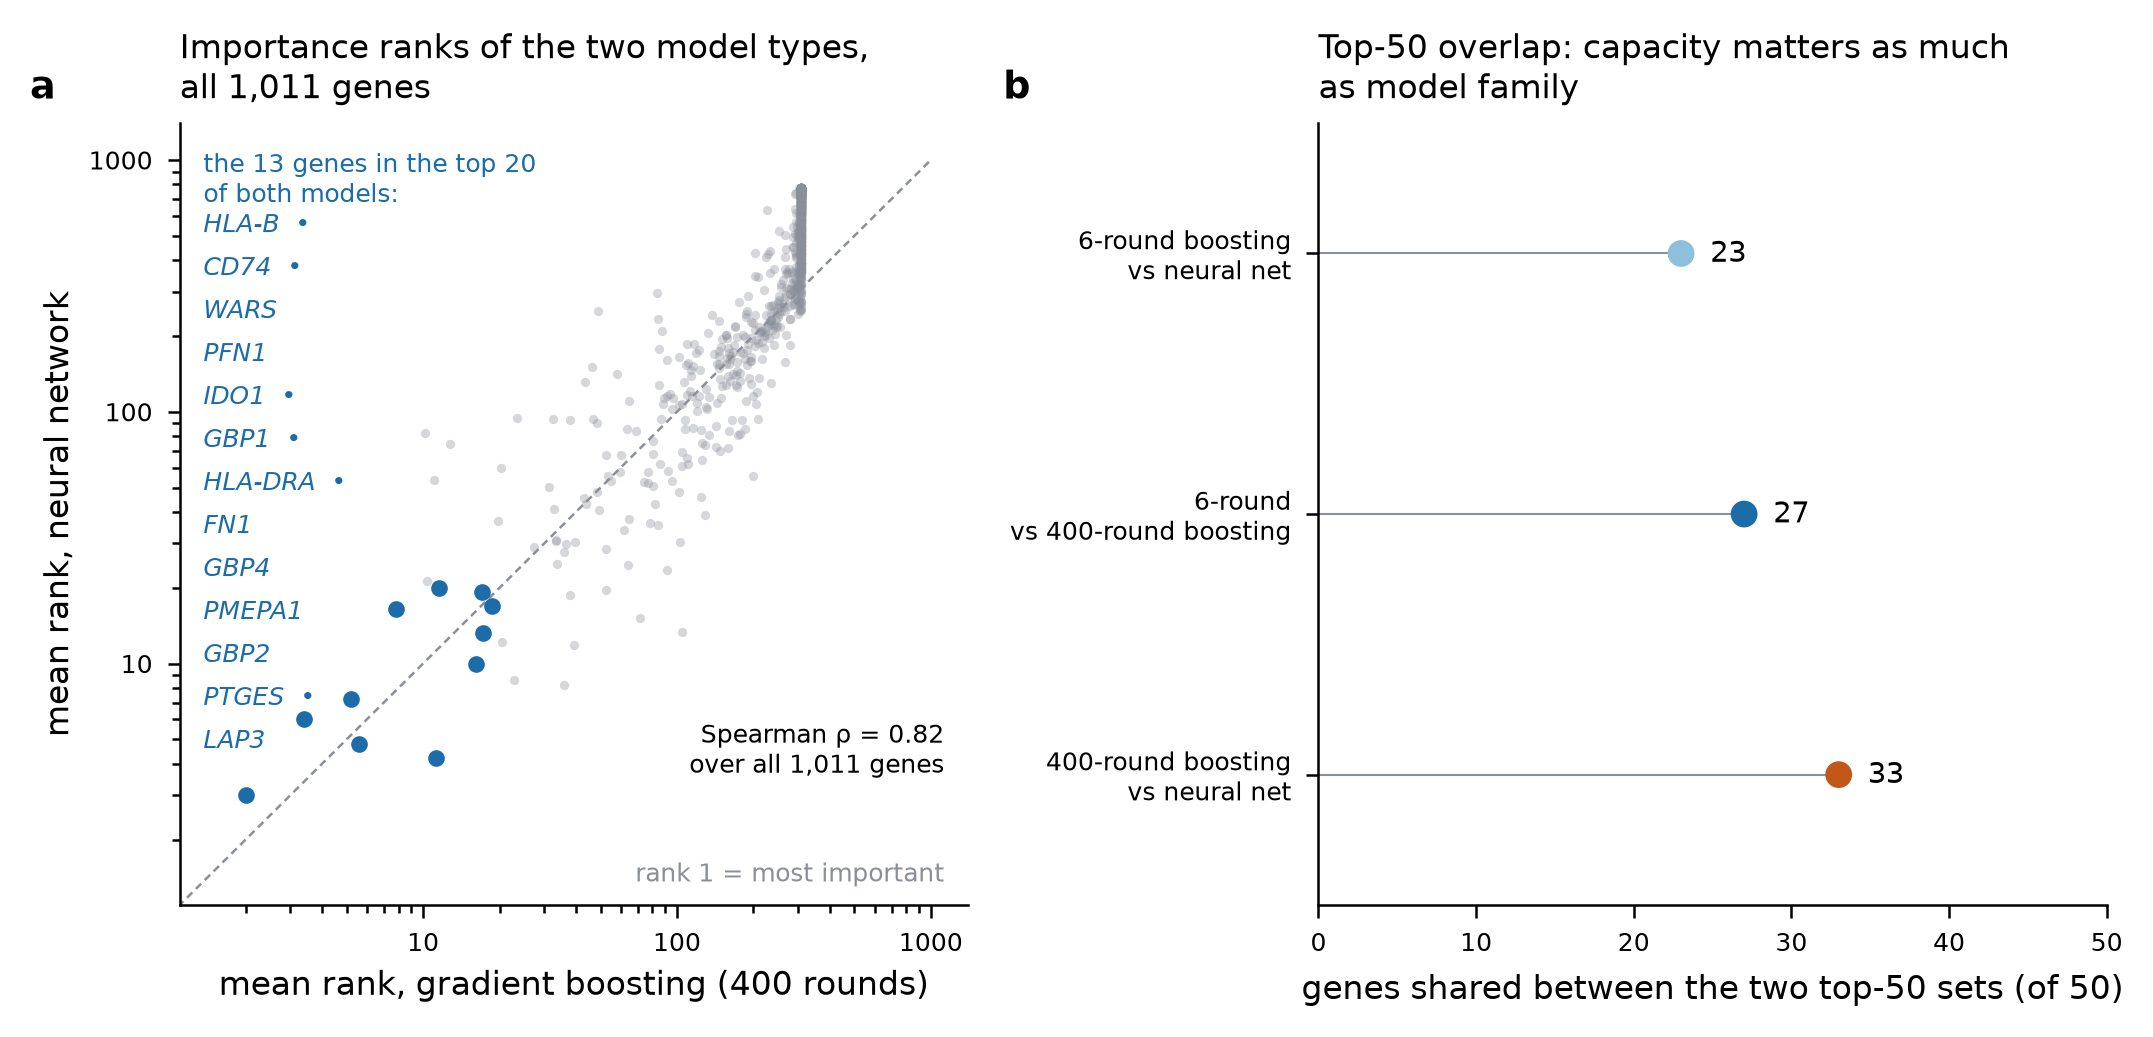

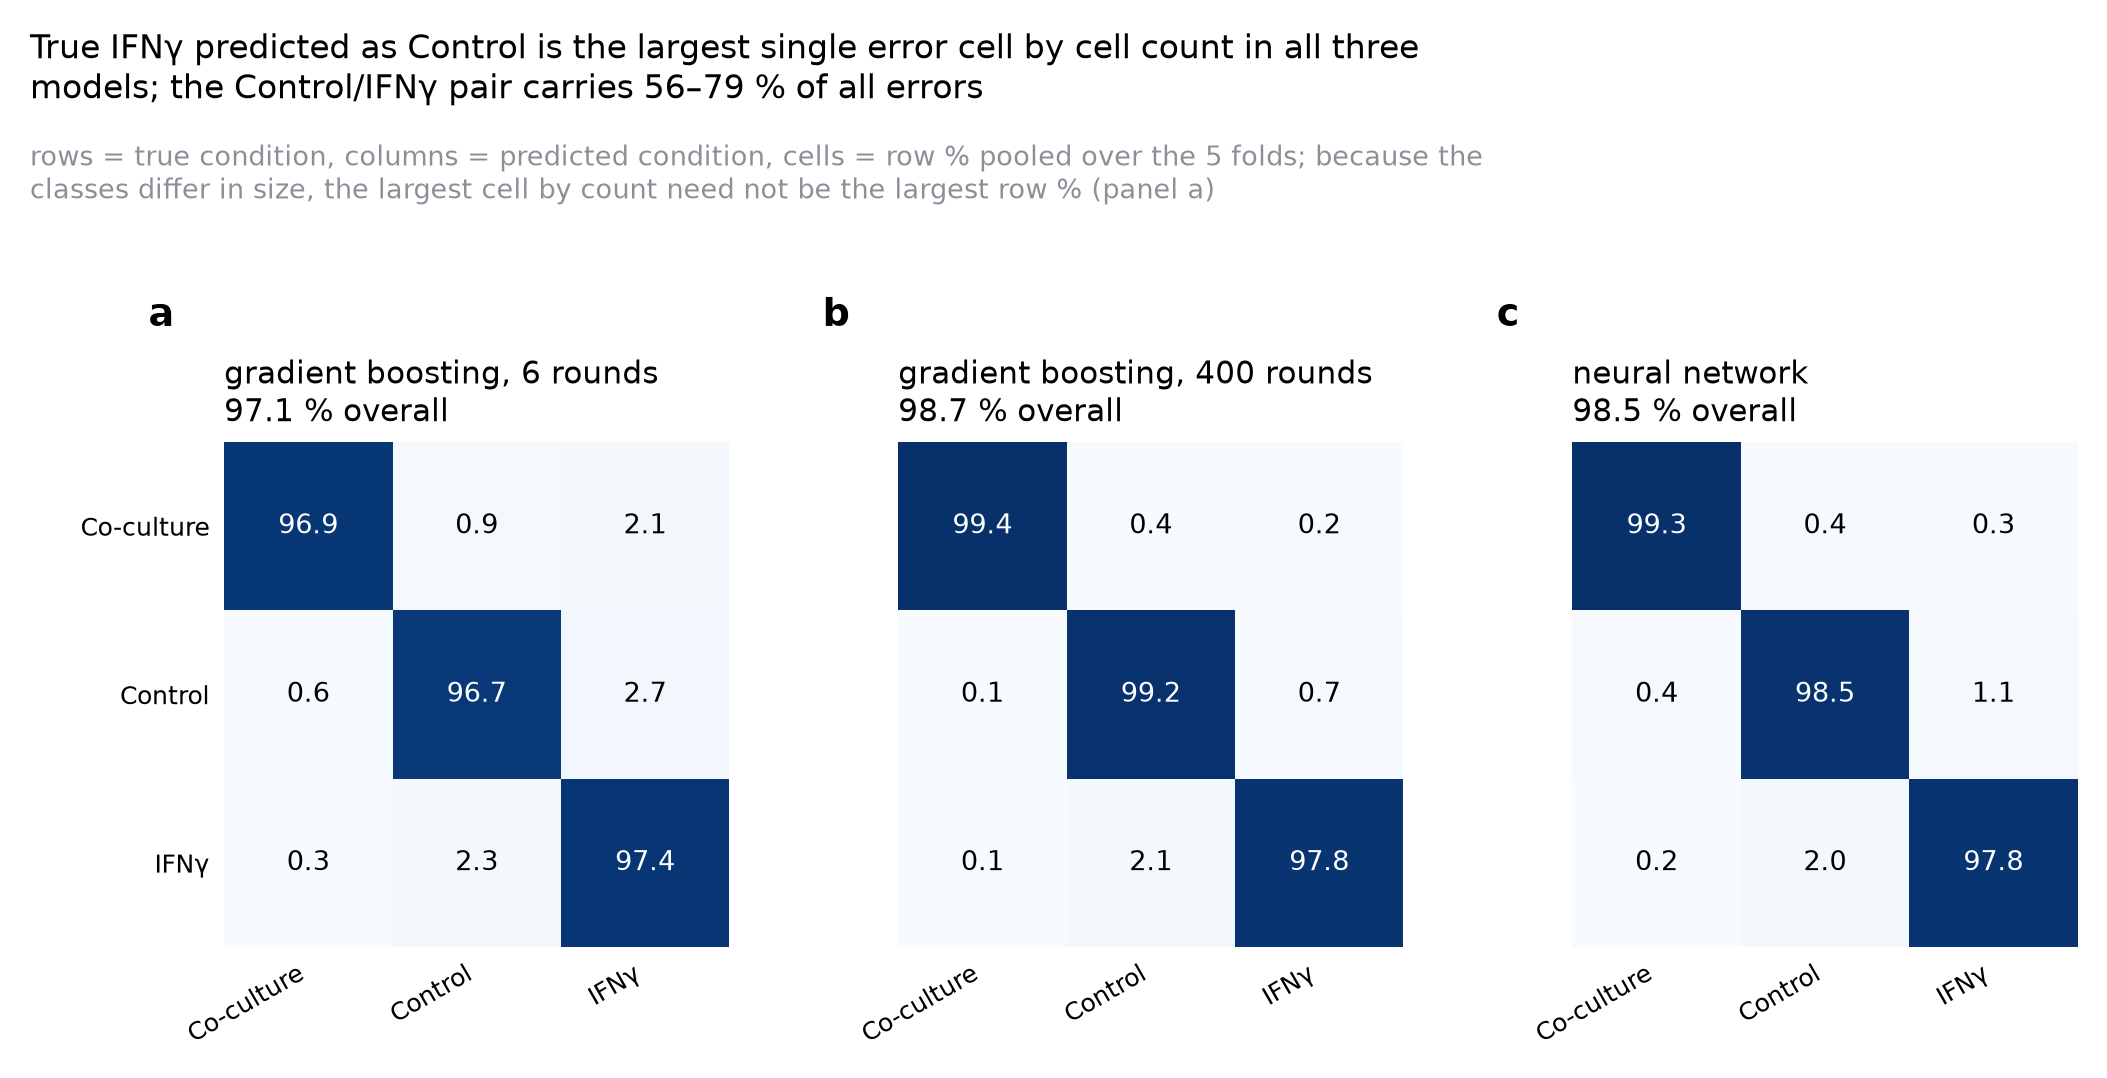

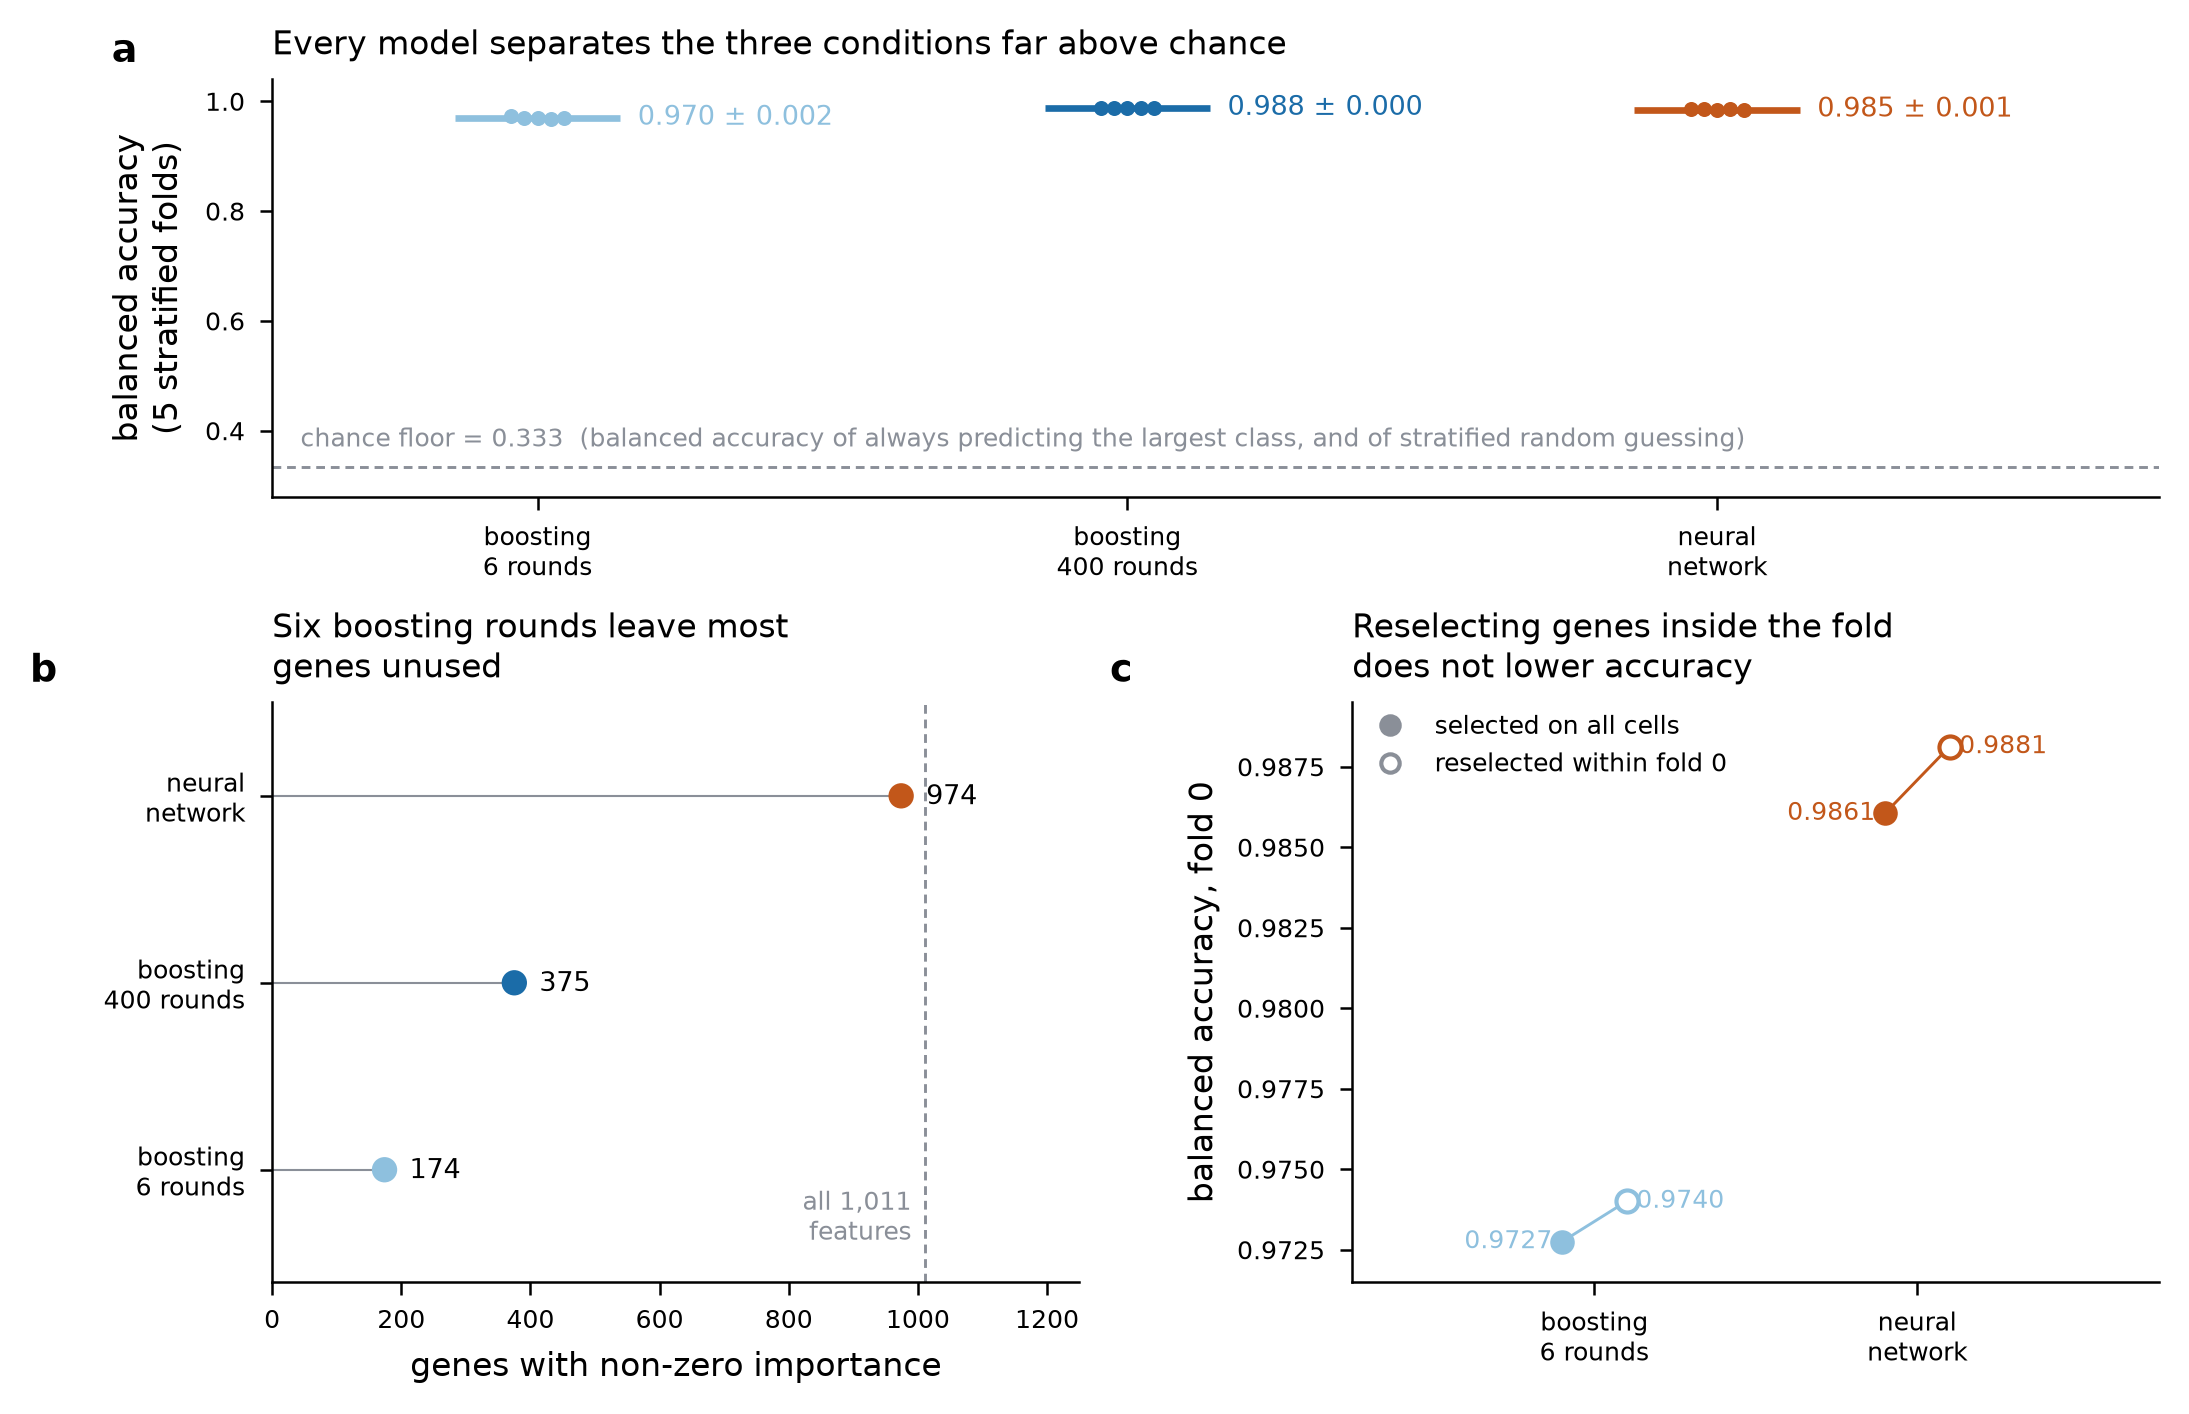

In [14]:
sys.path.insert(0, str(REPO / "tools"))
from IPython.display import Image, display
import task1_figures

task1_figures.main()
for name in sorted(pth.name for pth in (REPO / "figures").glob("task1_fig*.png")):
    display(Image(filename=str(REPO / "figures" / name)))
